# Iterative Methods Lab (Jacobi and CG) 

Direct methods (like LU or Cholesky) are $O(n^3)$ and require storing the matrix (often $O(n^2)$). For large sparse systems (e.g., $n=10^6$), direct methods are computationally impossible. Iterative methods:
1. Only require **matrix-vector products** ($Ax$).
2. Converge to a desired tolerance in much fewer than $n$ steps for well-behaved systems.
3. Preserve sparsity and minimize memory overhead.

In [1]:
import numpy as np
import numpy.linalg as npla
import scipy.sparse as sparse
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib import cm

## 1. Jacobi Iteration

### The Math
Split $A$ into its diagonal $D$ and off-diagonal $C$ ($A = D + C$). The system $Ax=b$ becomes:
$$Dx + Cx = b \implies x = D^{-1}(b - Cx)$$

The **Jacobi iteration** is:
$$x^{(k+1)} = D^{-1}(b - Cx^{(k)})$$

### Convergence
Jacobi converges if $A$ is **strictly diagonally dominant**:
$$|a_{ii}| > \sum_{j \neq i} |a_{ij}|$$
Intuitively, the diagonal elements must be "strong" enough to keep the iteration stable.

In [2]:
def Jsolve(A, b, tol=1e-8, max_iters=1000):
    """Jacobi Method using sparse matrices."""
    n = A.shape[0]
    d = A.diagonal()
    C = A.copy()
    C.setdiag(np.zeros(n))
    
    x = np.zeros(n)
    rel_res = [1.0]
    norm_b = npla.norm(b)
    
    for k in range(max_iters):
        x = (b - C @ x) / d
        res = npla.norm(b - A @ x) / norm_b
        rel_res.append(res)
        if res < tol:
            break
    return x, np.array(rel_res)

### Visualizing Jacobi (2D)
In 2D, each row is a line. Jacobi moves toward the intersection by updating $x_i$ using the other components from the *previous* step.

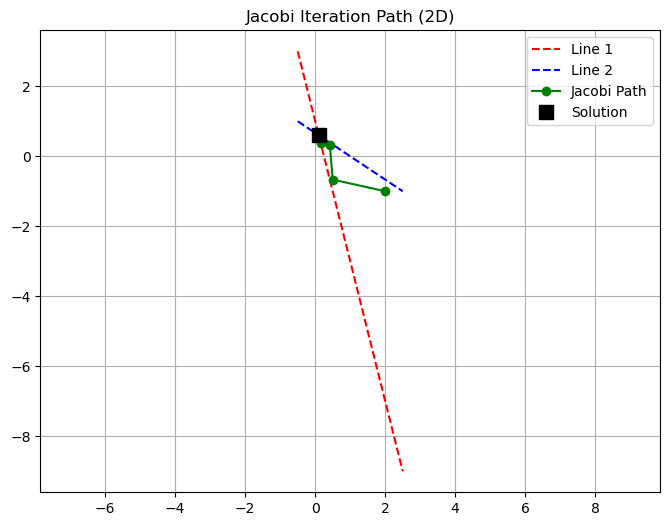

In [3]:
A_2d = sparse.csr_matrix([[4., 1.], [2., 3.]])
b_2d = np.array([1., 2.])
x_star = npla.solve(A_2d.toarray(), b_2d)

def get_jacobi_path(A, b, x0, steps):
    d = A.diagonal()
    C = A.copy()
    C.setdiag(np.zeros(A.shape[0]))
    x = x0.copy()
    path = [x.copy()]
    for _ in range(steps):
        x = (b - C @ x) / d
        path.append(x.copy())
    return np.array(path)

path = get_jacobi_path(A_2d, b_2d, np.array([2., -1.]), 10)

x_range = np.linspace(-0.5, 2.5, 200)
y1 = (b_2d[0] - A_2d[0,0]*x_range)/A_2d[0,1]
y2 = (b_2d[1] - A_2d[1,0]*x_range)/A_2d[1,1]

plt.figure(figsize=(8, 6))
plt.plot(x_range, y1, 'r--', label='Line 1')
plt.plot(x_range, y2, 'b--', label='Line 2')
plt.plot(path[:,0], path[:,1], 'go-', label='Jacobi Path')
plt.plot(x_star[0], x_star[1], 'ks', markersize=10, label='Solution')
plt.title("Jacobi Iteration Path (2D)")
plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()

## 2. Conjugate Gradient (CG) & Optimization Geometry

### The Optimization Perspective
For an SPD matrix $A$, solving $Ax=b$ is exactly equivalent to finding the minimum of the quadratic form:
$$f(x) = \frac{1}{2}x^T Ax - b^T x + c$$
The gradient $\nabla f(x) = Ax - b$ is the **negative residual** $-r$. 

### CG vs. Steepest Descent
*   **Steepest Descent:** Moves in the direction of the local gradient ($r_k$). On "narrow valleys" (poorly conditioned matrices), it zig-zags inefficiently.
*   **Conjugate Gradient:** Moves in directions $p_k$ that are **A-orthogonal** ($p_i^T A p_j = 0$). This ensures that minimizing along $p_k$ does not "spoil" the minimization already achieved along $p_{k-1}$.

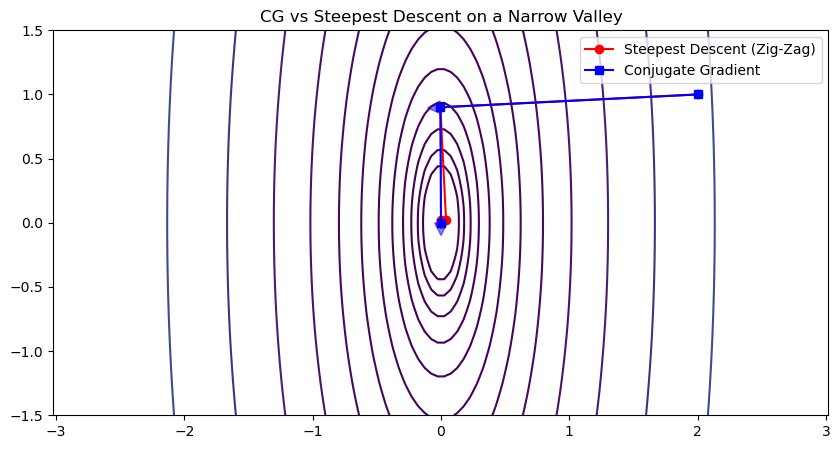

In [4]:
def steepest_descent(A, b, x0, steps):
    x = x0.copy()
    path = [x.copy()]
    for _ in range(steps):
        r = b - A @ x
        alpha = (r @ r) / (r @ (A @ r))
        x = x + alpha * r
        path.append(x.copy())
    return np.array(path)

def cg_path(A, b, x0, steps):
    x = x0.copy()
    r = b - A @ x
    p = r.copy()
    path = [x.copy()]
    directions = []
    for _ in range(steps):
        Ap = A @ p
        alpha = (r @ r) / (p @ Ap)
        directions.append(p * alpha)
        x = x + alpha * p
        path.append(x.copy())
        r_new = r - alpha * Ap
        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new
    return np.array(path), np.array(directions)

# Ill-conditioned SPD matrix
A_ill = np.array([[10, 0], [0, 1]])
b_ill = np.array([0, 0])
x0 = np.array([2, 1])

path_sd = steepest_descent(A_ill, b_ill, x0, 10)
path_cg, p_dirs = cg_path(A_ill, b_ill, x0, 2)

X, Y = np.meshgrid(np.linspace(-2.5, 2.5, 100), np.linspace(-1.5, 1.5, 100))
Z = 0.5*(A_ill[0,0]*X**2 + A_ill[1,1]*Y**2)

plt.figure(figsize=(10, 5))
plt.contour(X, Y, Z, levels=np.logspace(-1, 2, 15), cmap='viridis')
plt.plot(path_sd[:,0], path_sd[:,1], 'r-o', label='Steepest Descent (Zig-Zag)')
plt.plot(path_cg[:,0], path_cg[:,1], 'b-s', label='Conjugate Gradient')

# Plot search directions for CG
for i in range(len(p_dirs)):
    plt.arrow(path_cg[i,0], path_cg[i,1], p_dirs[i,0], p_dirs[i,1], 
              head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.5)

plt.title("CG vs Steepest Descent on a Narrow Valley")
plt.legend(); plt.axis('equal'); plt.show()

### Residual vs. Error
In the lab, we usually plot the **Residual Norm** $\|r_k\| = \|b - Ax_k\|$. However, CG is theoretically minimizing the **A-norm of the Error**:
$$\|e_k\|_A = \sqrt{e_k^T A e_k}, \quad \text{where } e_k = x^* - x_k$$

The residual can look "noisy" or flat while the actual error is still dropping significantly. 

**Key Technical Fact:** $f(x_k) - f(x^*) = \frac{1}{2}\|e_k\|_A^2$. CG is literally descending the energy bowl as fast as possible in $A$-orthogonal steps.

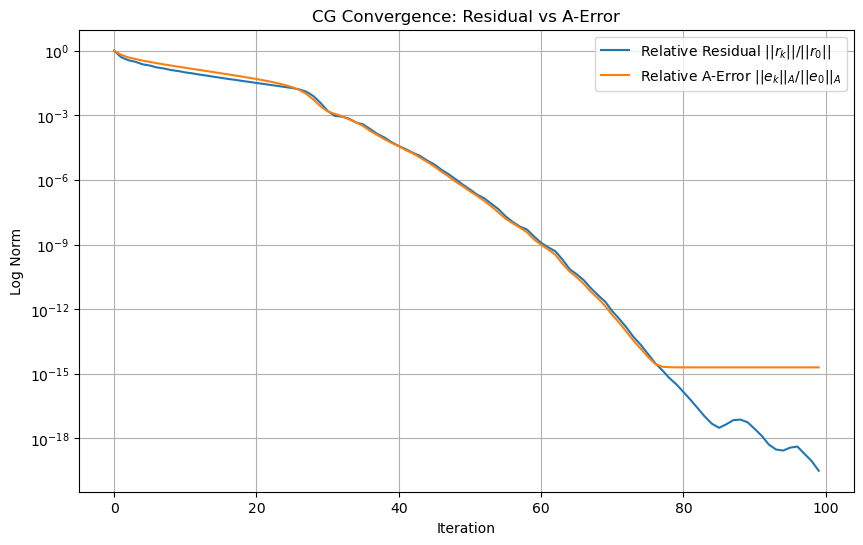

In [9]:
def CG_with_error(A, b, x_star):
    n = A.shape[0]
    x = np.zeros(n)
    r = b - A @ x
    p = r.copy()
    rtr = r @ r
    res_norms = []
    err_anorms = []
    
    for k in range(min(n, 100)):
        err = x_star - x
        err_anorms.append(np.sqrt(err @ (A @ err)))
        res_norms.append(np.sqrt(rtr))
        
        Ap = A @ p
        alpha = rtr / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        new_rtr = r @ r
        beta = new_rtr / rtr
        p = r + beta * p
        rtr = new_rtr
        
    return np.array(res_norms), np.array(err_anorms)

k_val = 20
A_p, b_p = make_poisson_problem(k_val)
x_star_p = spla.spsolve(A_p, b_p)
res_p, err_p = CG_with_error(A_p, b_p, x_star_p)

plt.figure(figsize=(10, 6))
plt.semilogy(res_p/res_p[0], label='Relative Residual $||r_k||/||r_0||$')
plt.semilogy(err_p/err_p[0], label='Relative A-Error $||e_k||_A/||e_0||_A$')
plt.title("CG Convergence: Residual vs A-Error")
plt.xlabel("Iteration"); plt.ylabel("Log Norm"); plt.legend(); plt.grid(True); plt.show()

## 3. The Performance Gap: Temperature Problem

We model heat distribution on a $k \times k$ grid. This results in the **Poisson Equation** system with $n = k^2$ unknowns. The matrix is large, sparse, and SPD.

In [10]:
def make_poisson_problem(k):
    """Create A and b for the 2D Poisson problem."""
    # A is a k^2 x k^2 matrix
    n = k*k
    # Main diagonal is 4, off-diagonals are -1
    main_diag = np.ones(n) * 4
    off_diag = np.ones(n-1) * -1
    # Remove couplings between grid rows
    for i in range(1, k):
        off_diag[i*k - 1] = 0
    
    upper_diag = np.ones(n-k) * -1
    
    A = sparse.diags([main_diag, off_diag, off_diag, upper_diag, upper_diag], 
                     [0, -1, 1, -k, k], format='csr')
    
    # Boundary conditions: radiator on one wall
    b = np.zeros(n)
    b[n-k : n] = 100.0 # Bottom wall is 100 degrees
    return A, b

k = 50 # Grid size (50x50 = 2500 variables)
A, b = make_poisson_problem(k)

print(f"Solving for n = {k*k} variables...")
x_j, res_j = Jsolve(A, b, max_iters=2000)
x_cg, res_cg = CGsolve(A, b, max_iters=2000)

plt.figure(figsize=(10, 6))
plt.semilogy(res_j, label='Jacobi')
plt.semilogy(res_cg, label='CG')
plt.axhline(1e-8, color='k', linestyle='--', label='Tolerance')
plt.xlabel('Iteration'); plt.ylabel('Relative Residual')
plt.title(f"Convergence Comparison (n={k*k})")
plt.legend(); plt.grid(True); plt.show()

Solving for n = 2500 variables...


NameError: name 'CGsolve' is not defined

### Summary Table

| Feature | Jacobi | Conjugate Gradient |
| :--- | :--- | :--- |
| **Requirement** | Diagonal Dominance (usually) | Symmetric Positive Definite (SPD) |
| **Speed** | Slow (Linear) | Fast (Superlinear) |
| **Per Iteration** | 1 Sparse Mat-Vec + 1 Div | 1 Sparse Mat-Vec + 2 Dots |
| **Geometry** | Local update of components | Global optimization of a bowl |
| **Final Verdict** | Good for preconditioning | Standard for large SPD systems |